# 10 Progress Tracker

**Tracks weight, body composition trends, and gives automatic AI recommendations.**

## Features
- Weight logging with trend analysis (moving average vs raw data)
- Automatic rate-of-change calculation vs expected from energy balance
- Program adjustment recommendations when progress stalls
- Plateau detection
- Visual progress charts
- AI coach feedback based on Henselmans principles

## Key design - Henselmans approach to progress tracking
- Weekly average weight (not daily) - reduces noise from water/food
- Expected rate from energy balance calculator
- 3-4 week minimum before adjusting calories
- Distinguish fat loss from muscle gain via trend + visual assessment

In [1]:
import json, os, sys
from pathlib import Path
from datetime import datetime, date, timedelta
from collections import deque
import statistics
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from openai import OpenAI
from dotenv import load_dotenv
from tenacity import retry, wait_exponential, stop_after_attempt
load_dotenv(override=True)

NOTEBOOK_DIR = Path().resolve()
BACKEND_DIR = NOTEBOOK_DIR.parent
DATA_DIR = BACKEND_DIR / 'data' / 'progress'
PROCESSED_DIR = BACKEND_DIR / 'data' / 'processed'
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Add calculators to path
sys.path.insert(0, str(BACKEND_DIR / 'tools'))
import calculators as Calc

openai_client = OpenAI(api_key=os.getenv('OPENAI_API_KEY'))
LLM_MODEL = os.getenv('PRIMARY_MODEL')

print('Setup complete')

Setup complete


## 1. Weight Log Data Model

In [2]:
class WeightLog:
    """
    Persistent weight log for a user.
    Stores daily entries, computes weekly averages and trend.
    """
    def __init__(self, user_id: str):
        self.user_id = user_id
        self.path = DATA_DIR / f'{user_id}_weight.json'
        self.entries = []
        self._load()

    def _load(self):
        if self.path.exists():
            data = json.loads(self.path.read_text(encoding='utf-8'))
            self.entries = data.get('entries', [])

    def save(self):
        self.path.write_text(
            json.dumps({'user_id': self.user_id, 'entries': self.entries},
                       ensure_ascii=False, indent=2), encoding='utf-8')

    def log(self, weight_kg: float, log_date: str = None, notes: str = ''):
        """Add a weight entry. Overwrites if same date already exists."""
        d = log_date or date.today().isoformat()
        # Remove existing entry for same date
        self.entries = [e for e in self.entries if e['date'] != d]
        self.entries.append({'date': d, 'weight_kg': weight_kg, 'notes': notes})
        self.entries.sort(key=lambda x: x['date'])
        self.save()
        return self.get_trend()

    def get_entries(self, days: int = None) -> list:
        if days:
            cutoff = (date.today() - timedelta(days=days)).isoformat()
            return [e for e in self.entries if e['date'] >= cutoff]
        return self.entries

    def weekly_averages(self) -> list[dict]:
        """
        Compute 7-day rolling average weight.
        This is the Henselmans method - weekly avg eliminates daily noise
        from water retention, food volume, etc.
        """
        if len(self.entries) < 3:
            return []

        avgs = []
        window = deque(maxlen=7)

        for entry in self.entries:
            window.append(entry['weight_kg'])
            if len(window) >= 3:
                avgs.append({
                    'date': entry['date'],
                    'avg_weight': round(statistics.mean(window), 2),
                    'raw_weight': entry['weight_kg'],
                })
        return avgs

    def get_trend(self) -> dict:
        """
        Compute trend statistics from the last 4 weeks of data.
        Returns rate of change, consistency, plateau detection.
        """
        recent = self.get_entries(days=28)
        if len(recent) < 4:
            return {'status': 'insufficient_data', 'weeks': len(recent) // 7}

        weights = [e['weight_kg'] for e in recent]
        dates = [e['date'] for e in recent]

        # Linear regression for trend line
        x = np.arange(len(weights))
        coeffs = np.polyfit(x, weights, 1)
        slope = coeffs[0]  # kg per data point

        # Weekly rate (assuming ~daily logging)
        weekly_rate = slope * 7

        first_w = statistics.mean(weights[:7]) if len(weights) >= 7 else weights[0]
        last_w = statistics.mean(weights[-7:]) if len(weights) >= 7 else weights[-1]
        actual_change_4w = last_w - first_w

        return {
            'status': 'ok',
            'entries_count': len(recent),
            'start_weight': round(first_w, 2),
            'current_weight': round(last_w, 2),
            'total_change_kg': round(actual_change_4w, 2),
            'weekly_rate_kg': round(weekly_rate, 2),
            'direction': 'down' if weekly_rate < -0.05 else 'up' if weekly_rate > 0.05 else 'stable',
        }

    def clear(self):
        self.entries = []
        self.save()


print('WeightLog defined')

WeightLog defined


## 2. Generate Realistic Test Data

In [3]:
import random
random.seed(42)

def generate_test_data(user_id: str, start_weight: float, weekly_change: float,
                        weeks: int = 12, noise_std: float = 0.4):
    """Generate realistic weight data with daily noise (water retention etc.)"""
    log = WeightLog(user_id)
    log.clear()

    current = start_weight
    start = date.today() - timedelta(days=weeks * 7)

    for week in range(weeks):
        expected_change = weekly_change / 7  # daily change
        for day in range(7):
            d = start + timedelta(days=week*7 + day)
            noise = random.gauss(0, noise_std)
            # Skip some days (realistic - not everyone logs every day)
            if random.random() < 0.75:  # 75% logging rate
                log.log(round(current + noise, 1), d.isoformat())
            current += expected_change

    print(f'Generated {len(log.entries)} entries over {weeks} weeks')
    trend = log.get_trend()
    print(f'Start: {trend["start_weight"]} kg → Current: {trend["current_weight"]} kg')
    print(f'Total change: {trend["total_change_kg"]:+.2f} kg')
    print(f'Weekly rate: {trend["weekly_rate_kg"]:+.3f} kg/week')
    return log


# Intermediate male, cutting — expected -0.5 kg/week
log = generate_test_data('test_001', start_weight=88.0, weekly_change=-0.5, weeks=12)

Generated 66 entries over 12 weeks
Start: 83.69 kg → Current: 82.39 kg
Total change: -1.30 kg
Weekly rate: -0.640 kg/week


## 3. Progress Analysis

In [4]:
def analyze_progress(weight_log: WeightLog, user_profile: dict,
                      calc_results: dict) -> dict:
    """
    Compare actual weight change vs expected from energy balance.
    Detect plateau, assess if adjustments needed.
    Follows Henselmans 3-4 week minimum before adjusting.
    """
    trend = weight_log.get_trend()
    if trend['status'] == 'insufficient_data':
        return {'status': 'insufficient_data',
                'message': f'Need at least 4 entries. Have: {trend["weeks"]} weeks'}

    # Expected rate from energy balance
    goal = calc_results['goal_validation'].recommended_goal
    energy = calc_results['energy']

    # Expected weekly change based on caloric deficit/surplus
    # Cut: -500 kcal/day = -3500 kcal/week ÷ 7700 kcal/kg = -0.45 kg/week
    # Bulk: +250 kcal/day = +1750 kcal/week ÷ 7700 = +0.23 kg/week
    deficit_surplus = energy.target_kcal - energy.tdee_kcal
    expected_weekly = round(deficit_surplus * 7 / 7700, 3)

    actual_weekly = trend['weekly_rate_kg']
    discrepancy = actual_weekly - expected_weekly
    tolerance = 0.1  # kg/week - acceptable variance

    # Plateau detection: < 0.1 kg/week change when expecting more
    is_plateau = (abs(actual_weekly) < 0.1 and
                  abs(expected_weekly) > 0.2 and
                  trend['entries_count'] >= 14)

    # Progress assessment
    if is_plateau:
        status = 'plateau'
    elif abs(discrepancy) <= tolerance:
        status = 'on_track'
    elif (goal in ('cut', 'aggressive_cut') and actual_weekly > expected_weekly + tolerance):
        status = 'too_slow_loss'
    elif (goal in ('cut', 'aggressive_cut') and actual_weekly < expected_weekly - tolerance):
        status = 'too_fast_loss'
    elif (goal == 'bulk' and actual_weekly < expected_weekly - tolerance):
        status = 'too_slow_gain'
    elif (goal == 'bulk' and actual_weekly > expected_weekly + tolerance):
        status = 'too_fast_gain'
    else:
        status = 'on_track'

    return {
        'status': status,
        'goal': goal,
        'actual_weekly_kg': actual_weekly,
        'expected_weekly_kg': expected_weekly,
        'discrepancy_kg': round(discrepancy, 3),
        'is_plateau': is_plateau,
        'entries_count': trend['entries_count'],
        'total_change_kg': trend['total_change_kg'],
        'current_weight': trend['current_weight'],
        'start_weight': trend['start_weight'],
        'weeks_tracked': round(trend['entries_count'] / 7, 1),
    }

calc_mock = Calc.run_all_calculators({
    'bodyweight_kg': 88, 'body_fat_pct': 18,
    'activity_level': 'moderate', 'goal': 'cut',
    'training_days_per_week': 4, 'sex': 'male',
    'training_status': 2, 'lifts': {
        'bench': {'weight': 100, 'reps': 5},
    }
})

analysis = analyze_progress(log, {}, calc_mock)
print('PROGRESS ANALYSIS:')
for k, v in analysis.items():
    print(f'  {k:<22}: {v}')

PROGRESS ANALYSIS:
  status                : too_fast_loss
  goal                  : cut
  actual_weekly_kg      : -0.64
  expected_weekly_kg    : -0.455
  discrepancy_kg        : -0.185
  is_plateau            : False
  entries_count         : 20
  total_change_kg       : -1.3
  current_weight        : 82.39
  start_weight          : 83.69
  weeks_tracked         : 2.9


## 4. AI Coach Feedback

In [6]:
COACH_SYSTEM = """Ти си персонален фитнес треньор по методологията на Menno Henselmans.
Давай кратка, конкретна обратна връзка за прогреса на клиента.
ПРАВИЛА: Само на БЪЛГАРСКИ. Само килограми. Директно и практично. Без излишни думи."""

@retry(wait=wait_exponential(min=1, max=20), stop=stop_after_attempt(3))
def generate_progress_feedback(analysis: dict, user_profile: dict) -> str:
    """Generate Bulgarian AI coach feedback based on progress analysis."""

    status_descriptions = {
        'on_track': 'Прогресът е точно по план.',
        'plateau': 'Теглото е в застой - нужна е корекция.',
        'too_slow_loss': 'Теглото спада по-бавно от очакваното.',
        'too_fast_loss': 'Теглото спада прекалено бързо - риск от загуба на мускулна маса.',
        'too_slow_gain': 'Теглото се покачва по-бавно от очакваното.',
        'too_fast_gain': 'Теглото се покачва прекалено бързо - вероятно мазнини.',
    }

    prompt = f"""Анализ на прогреса:
- Статус: {status_descriptions.get(analysis['status'], analysis['status'])}
- Цел: {analysis['goal']}
- Очаквана промяна: {analysis['expected_weekly_kg']:+.2f} кг/седмица
- Реална промяна: {analysis['actual_weekly_kg']:+.2f} кг/седмица
- Общо за {analysis['weeks_tracked']:.1f} седмици: {analysis['total_change_kg']:+.2f} кг
- Текущо тегло: {analysis['current_weight']} кг
- Плато: {'Да' if analysis['is_plateau'] else 'Не'}

Дай кратка (3-5 изречения) конкретна препоръка:
1. Как да интерпретира резултата
2. Дали трябва да коригира калориите (и с колко точно)
3. Следващи стъпки

Отговаряй само на БЪЛГАРСКИ."""

    r = openai_client.chat.completions.create(
        model = LLM_MODEL,
        messages = [{'role': 'system', 'content': COACH_SYSTEM},
                       {'role': 'user', 'content': prompt}],
        temperature = 0.3,
        max_tokens = 300,
    )
    return r.choices[0].message.content


feedback = generate_progress_feedback(analysis, {})
print('AI COACH FEEDBACK:')
print('=' * 55)
print(feedback)

AI COACH FEEDBACK:
Резултатът показва, че губиш тегло прекалено бързо, което може да доведе до загуба на мускулна маса. Препоръчвам да увеличиш калорийния прием с около 100-150 калории на ден, за да забавиш темпото на отслабване. Следи прогреса си и коригирай отново след 2-3 седмици. Фокусирай се на качеството на храната и поддържай силовите тренировки, за да запазиш мускулната маса.


## 5. Visualization - Weight Progress Chart

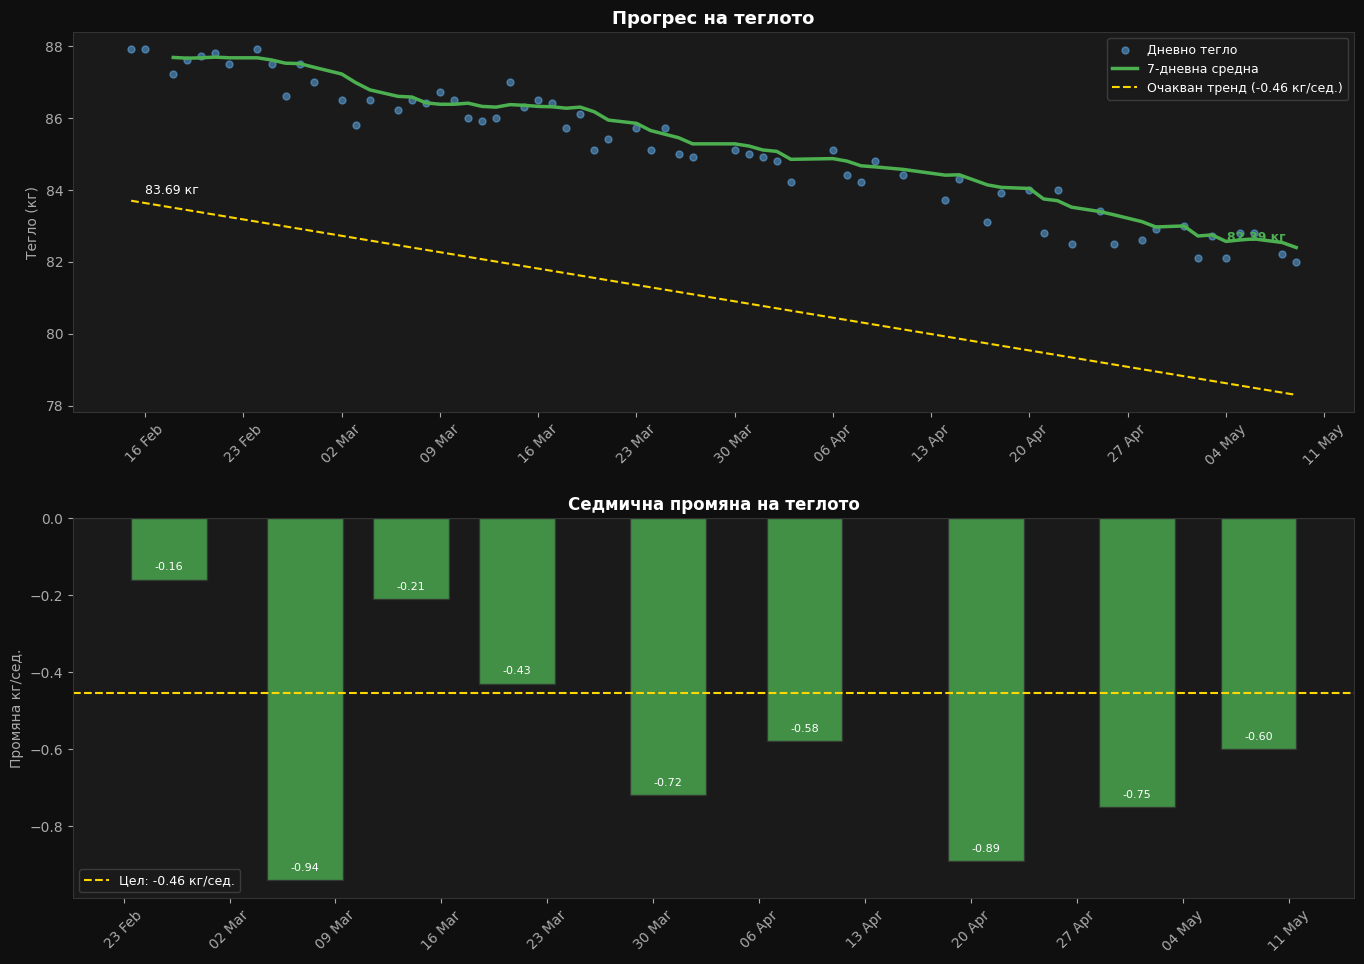

Chart saved -> D:\Cybernetic Gym Assistant\backend\data\progress\progress_chart.png


In [7]:
def plot_progress(weight_log: WeightLog, analysis: dict, user_profile: dict = {}):
    """
    Professional weight progress chart:
    - Raw daily weights (dots)
    - 7-day rolling average (trend line)
    - Expected progress line from energy balance
    - Annotations for key events
    """
    entries = weight_log.get_entries()
    if len(entries) < 4:
        print('Not enough data for chart')
        return

    dates_raw = [datetime.strptime(e['date'], '%Y-%m-%d') for e in entries]
    weights_raw = [e['weight_kg'] for e in entries]

    weekly_avgs = weight_log.weekly_averages()
    dates_avg = [datetime.strptime(w['date'], '%Y-%m-%d') for w in weekly_avgs]
    weights_avg = [w['avg_weight'] for w in weekly_avgs]

    # Expected trend line from start
    start_w = analysis['start_weight']
    weekly_exp = analysis['expected_weekly_kg']
    n_days = (dates_raw[-1] - dates_raw[0]).days
    dates_exp = [dates_raw[0] + timedelta(days=i) for i in range(n_days+1)]
    weights_exp = [start_w + (weekly_exp / 7) * i for i in range(n_days+1)]

    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    fig.patch.set_facecolor('#0f0f0f')

    # Plot 1: Weight over time
    ax1 = axes[0]
    ax1.set_facecolor('#1a1a1a')
    ax1.set_title('Прогрес на теглото', color='white', fontsize=13, fontweight='bold')

    # Raw data points
    ax1.scatter(dates_raw, weights_raw, color='#64B5F6', s=25, alpha=0.5,
                zorder=2, label='Дневно тегло')
    # 7-day rolling average
    ax1.plot(dates_avg, weights_avg, color='#4CAF50', linewidth=2.5,
             zorder=3, label='7-дневна средна')
    # Expected trend
    ax1.plot(dates_exp, weights_exp, color='#FFD700', linewidth=1.5,
             linestyle='--', zorder=3, label=f'Очакван тренд ({weekly_exp:+.2f} кг/сед.)')

    # Annotate start and current
    ax1.annotate(f'{start_w} кг', (dates_raw[0], start_w),
                 textcoords='offset points', xytext=(10, 5),
                 color='white', fontsize=9)
    ax1.annotate(f'{analysis["current_weight"]} кг',
                 (dates_raw[-1], analysis["current_weight"]),
                 textcoords='offset points', xytext=(-50, 5),
                 color='#4CAF50', fontsize=9, fontweight='bold')

    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    ax1.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, color='#aaa')
    ax1.tick_params(colors='#aaa')
    ax1.set_ylabel('Тегло (кг)', color='#aaa')
    ax1.legend(facecolor='#1a1a1a', edgecolor='#444', labelcolor='white', fontsize=9)
    for spine in ax1.spines.values(): spine.set_edgecolor('#333')

    # Plot 2: Weekly rate bar chart
    ax2 = axes[1]
    ax2.set_facecolor('#1a1a1a')
    ax2.set_title('Седмична промяна на теглото', color='white', fontsize=12, fontweight='bold')

    # Compute week-over-week change from weekly averages
    if len(weekly_avgs) >= 2:
        week_dates = []
        week_changes = []
        step = 7
        for i in range(step, len(weekly_avgs), step):
            if i < len(weekly_avgs):
                change = weekly_avgs[i]['avg_weight'] - weekly_avgs[i-step]['avg_weight']
                week_dates.append(datetime.strptime(weekly_avgs[i]['date'], '%Y-%m-%d'))
                week_changes.append(round(change, 2))

        colors = ['#4CAF50' if c < 0 else '#EF5350' for c in week_changes]
        bars = ax2.bar(week_dates, week_changes, color=colors, alpha=0.8,
                          width=5, edgecolor='#333')
        ax2.axhline(weekly_exp, color='#FFD700', linestyle='--', linewidth=1.5,
                    label=f'Цел: {weekly_exp:+.2f} кг/сед.')
        ax2.axhline(0, color='#555', linewidth=0.8)

        for bar, val in zip(bars, week_changes):
            ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height() + 0.02,
                     f'{val:+.2f}', ha='center', va='bottom', color='white', fontsize=8)

    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    ax2.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, color='#aaa')
    ax2.tick_params(colors='#aaa')
    ax2.set_ylabel('Промяна кг/сед.', color='#aaa')
    ax2.legend(facecolor='#1a1a1a', edgecolor='#444', labelcolor='white', fontsize=9)
    for spine in ax2.spines.values(): spine.set_edgecolor('#333')

    plt.tight_layout(pad=2)
    out = DATA_DIR / 'progress_chart.png'
    plt.savefig(str(out), dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
    plt.show()
    print(f'Chart saved -> {out}')


plot_progress(log, analysis)

## 6. Calorie Adjustment Recommendation

In [8]:
def recommend_calorie_adjustment(analysis: dict, current_target: float) -> dict:
    """
    Henselmans-based calorie adjustment logic.
    Only recommends adjustment after 3+ weeks of consistent data.
    Small adjustments (100-200 kcal) to avoid overshooting.
    """
    if analysis['entries_count'] < 14:
        return {
            'adjust': False,
            'reason': f'Само {analysis["entries_count"]} записа - изчакай поне 3 седмици преди корекция',
            'new_target': current_target,
        }

    status = analysis['status']
    adjustment = 0
    reason = ''

    if status == 'on_track':
        return {'adjust': False, 'reason': 'Прогресът е по план - не е нужна корекция',
                'new_target': current_target}

    elif status == 'plateau' or status == 'too_slow_loss':
        adjustment = -150   # reduce by 150 kcal
        reason  = f'Теглото не спада достатъчно. Намали със 150 ккал и наблюдавай 2 седмици.'

    elif status == 'too_fast_loss':
        adjustment = +200   # increase by 200 kcal
        reason     = f'Теглото спада прекалено бързо (>{abs(analysis["actual_weekly_kg"]):.2f} кг/сед.) - риск от загуба на мускулна маса. Добави 200 ккал.'

    elif status == 'too_slow_gain':
        adjustment = +150
        reason = f'Теглото не се покачва достатъчно. Добави 150 ккал.'

    elif status == 'too_fast_gain':
        adjustment = -150
        reason = f'Теглото се покачва прекалено бързо - вероятно мазнини. Намали със 150 ккал.'

    new_target = round(current_target + adjustment)

    return {
        'adjust': adjustment != 0,
        'adjustment_kcal': adjustment,
        'new_target': new_target,
        'old_target': current_target,
        'reason': reason,
        'weeks_of_data': round(analysis['entries_count'] / 7, 1),
    }


adj = recommend_calorie_adjustment(analysis, current_target=2405)
print('CALORIE ADJUSTMENT RECOMMENDATION:')
print('=' * 50)
print(f'  Status: {analysis["status"]}')
print(f'  Adjust needed: {adj["adjust"]}')
if adj['adjust']:
    print(f'  Old target: {adj["old_target"]} kcal')
    print(f'  Adjustment: {adj["adjustment_kcal"]:+d} kcal')
    print(f'  New target: {adj["new_target"]} kcal')
print(f'  Reason: {adj["reason"]}')

CALORIE ADJUSTMENT RECOMMENDATION:
  Status: too_fast_loss
  Adjust needed: True
  Old target: 2405 kcal
  Adjustment: +200 kcal
  New target: 2605 kcal
  Reason: Теглото спада прекалено бързо (>0.64 кг/сед.) - риск от загуба на мускулна маса. Добави 200 ккал.


## 7. Weekly Check-in - Full Report

In [9]:
def weekly_checkin(user_id: str, weight_log: WeightLog,
                    user_profile: dict, calc_results: dict,
                    current_calorie_target: float) -> dict:
    """
    Full weekly check-in report combining:
    - Progress analysis
    - Calorie adjustment recommendation
    - AI coach feedback
    """
    analysis = analyze_progress(weight_log, user_profile, calc_results)
    adjustment = recommend_calorie_adjustment(analysis, current_calorie_target)
    feedback = generate_progress_feedback(analysis, user_profile)

    report = {
        'date': date.today().isoformat(),
        'user_id': user_id,
        'analysis': analysis,
        'adjustment': adjustment,
        'coach_feedback': feedback,
    }

    print('=' * 60)
    print('  СЕДМИЧЕН CHECK-IN ДОКЛАД')
    print('=' * 60)
    print()
    print(f'  Период: {analysis["weeks_tracked"]:.1f} седмици')
    print(f'  Начално тегло: {analysis["start_weight"]} кг')
    print(f'  Текущо тегло: {analysis["current_weight"]} кг')
    print(f'  Промяна: {analysis["total_change_kg"]:+.2f} кг')
    print(f'  Темп/седмица: {analysis["actual_weekly_kg"]:+.3f} кг (цел: {analysis["expected_weekly_kg"]:+.3f})')
    print(f'  Статус: {analysis["status"].upper()}')
    print()
    if adjustment['adjust']:
        print(f'📊 КАЛОРИЙНА КОРЕКЦИЯ:')
        print(f'{adjustment["old_target"]} → {adjustment["new_target"]} kcal ({adjustment["adjustment_kcal"]:+d})')
        print(f'{adjustment["reason"]}')
    else:
        print(f'✅ Не е нужна калорийна корекция')
    print()
    print('🤖 AI ТРЕНЬОР:')
    print()
    for line in feedback.split('\n'):
        print(f'{line}')

    return report


report = weekly_checkin('test_001', log, {}, calc_mock, current_calorie_target=2405)

  СЕДМИЧЕН CHECK-IN ДОКЛАД

  Период: 2.9 седмици
  Начално тегло: 83.69 кг
  Текущо тегло: 82.39 кг
  Промяна: -1.30 кг
  Темп/седмица: -0.640 кг (цел: -0.455)
  Статус: TOO_FAST_LOSS

📊 КАЛОРИЙНА КОРЕКЦИЯ:
2405 → 2605 kcal (+200)
Теглото спада прекалено бързо (>0.64 кг/сед.) - риск от загуба на мускулна маса. Добави 200 ккал.

🤖 AI ТРЕНЬОР:

Резултатът показва, че губиш тегло прекалено бързо, което може да доведе до загуба на мускулна маса. Препоръчвам да увеличиш калориите с около 100-150 ккал на ден, за да забавиш темпото на отслабване. Следи прогреса си и ако теглото продължи да спада бързо, коригирай отново калориите. Фокусирай се и върху поддържане на силови тренировки, за да запазиш мускулната маса.


## 8. Summary

In [10]:
print('=' * 60)
print('  NOTEBOOK 10 - COMPLETE')
print('=' * 60)
print()
print('  Progress tracking features:')
print('  - WeightLog.log(): add daily weight entry')
print('  - WeightLog.weekly_averages(): 7-day rolling average')
print('  - analyze_progress(): actual vs expected rate')
print('  - recommend_calorie_adjustment(): Henselmans-based adj.')
print('  - generate_progress_feedback(): AI coach in Bulgarian')
print('  - plot_progress(): visual weight chart')
print('  - weekly_checkin(): full weekly report')
print()
print('  Design principles:')
print('  - Weekly average weight (not daily) - reduces noise')
print('  - 3+ weeks before calorie adjustment')
print('  - Small adjustments (100-200 kcal) to avoid overshoot')

  NOTEBOOK 10 - COMPLETE

  Progress tracking features:
  - WeightLog.log(): add daily weight entry
  - WeightLog.weekly_averages(): 7-day rolling average
  - analyze_progress(): actual vs expected rate
  - recommend_calorie_adjustment(): Henselmans-based adj.
  - generate_progress_feedback(): AI coach in Bulgarian
  - plot_progress(): visual weight chart
  - weekly_checkin(): full weekly report

  Design principles:
  - Weekly average weight (not daily) - reduces noise
  - 3+ weeks before calorie adjustment
  - Small adjustments (100-200 kcal) to avoid overshoot
